## 1. Load data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Load master table
data = pd.read_csv(Path("..") / "data" / "processed" / "merged" / "master_occupations.csv")

print(f'Shape: {data.shape}')
print(f'Missing values: {data.isnull().sum().sum()}')
print(f'Occupations: {data["OCC_CODE"].nunique()}')

Shape: (655, 122)
Missing values: 68
Occupations: 655


## 2. Feature Preparation

In [35]:
# Define the 93 O*NET feature columns
exclude = [
    'OCC_CODE', 'OCC_TITLE', 'occ_major_group',
    'AIOE', 'AIOE_z',
    'TOT_EMP_2019', 'TOT_EMP_2022', 'TOT_EMP_2024',
    'real_median_wage_2019', 'real_median_wage_2022', 'real_median_wage_2024',
    'emp_change_pct_19_24', 'emp_change_pct_19_22', 'emp_change_pct_22_24',
    'wage_change_pct_19_24', 'wage_change_pct_19_22', 'wage_change_pct_22_24'
]

feature_cols = [
    c for c in data.columns
    if c not in exclude and not c.startswith('A_PCT')
]

print(f'Feature columns: {len(feature_cols)}')
print(f'Missing in features: {data[feature_cols].isnull().sum().sum()}')
print(f'\nAbility features (52): {feature_cols[:3]} ...')
print(f'Work activity features (41): {feature_cols[52:55]} ...')

Feature columns: 93
Missing in features: 0

Ability features (52): ['arm_hand_steadiness', 'auditory_attention', 'category_flexibility'] ...
Work activity features (41): ['analyzing_data_or_information', 'assisting_and_caring_for_others', 'coaching_and_developing_others'] ...


In [36]:
# Standardize features to mean=0, std=1
# Required before PCA so no feature dominates due to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[feature_cols])

print(f'Scaled matrix shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean():.6f}')
print(f'Std  (should be ~1): {X_scaled.std():.6f}')

Scaled matrix shape: (655, 93)
Mean (should be ~0): 0.000000
Std  (should be ~1): 1.000000


## 3. PCA — Dimensionality Reduction

In [37]:
# Run PCA with 20 components
N_COMPONENTS = 20
pca = PCA(n_components=N_COMPONENTS, random_state=42)
components = pca.fit_transform(X_scaled)

# Explained variance report
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

print('Explained variance by component:')
print(f'{"Component":<12} {"Variance":<12} {"Cumulative":<12}')
print('-' * 36)
for i, (ev, cv) in enumerate(zip(exp_var, cum_var)):
    marker = ' <-- 80%' if abs(cv - 0.80) < 0.02 else (' <-- 90%' if abs(cv - 0.90) < 0.02 else '')
    print(f'PC{i+1:<10} {ev:<12.4f} {cv:<12.4f}{marker}')

n_80 = np.argmax(cum_var >= 0.80) + 1
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f'\nComponents needed for 80% variance: {n_80}')
print(f'Components needed for 90% variance: {n_90}')

Explained variance by component:
Component    Variance     Cumulative  
------------------------------------
PC1          0.3909       0.3909      
PC2          0.1802       0.5711      
PC3          0.0683       0.6394      
PC4          0.0380       0.6773      
PC5          0.0304       0.7078      
PC6          0.0249       0.7327      
PC7          0.0213       0.7540      
PC8          0.0189       0.7729      
PC9          0.0164       0.7892       <-- 80%
PC10         0.0115       0.8007       <-- 80%
PC11         0.0113       0.8120       <-- 80%
PC12         0.0094       0.8215      
PC13         0.0084       0.8299      
PC14         0.0082       0.8380      
PC15         0.0074       0.8455      
PC16         0.0068       0.8523      
PC17         0.0066       0.8589      
PC18         0.0061       0.8650      
PC19         0.0057       0.8706      
PC20         0.0054       0.8760      

Components needed for 80% variance: 10
Components needed for 90% variance: 1


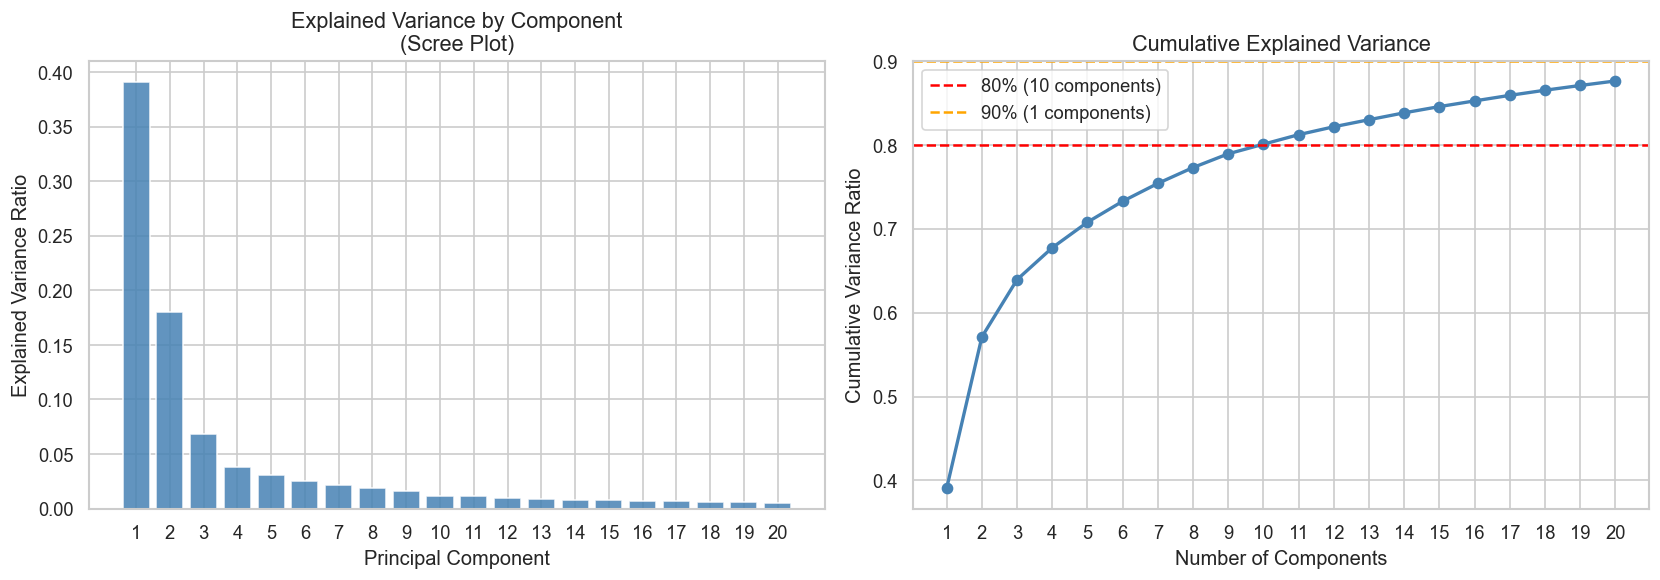

In [38]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, N_COMPONENTS + 1), exp_var,
            color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Explained Variance by Component\n(Scree Plot)', fontsize=13)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_xticks(range(1, N_COMPONENTS + 1))

axes[1].plot(range(1, N_COMPONENTS + 1), cum_var,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(0.80, color='red', linestyle='--',
                label=f'80% ({n_80} components)')
axes[1].axhline(0.90, color='orange', linestyle='--',
                label=f'90% ({n_90} components)')
axes[1].set_title('Cumulative Explained Variance', fontsize=13)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].legend()
axes[1].set_xticks(range(1, N_COMPONENTS + 1))

plt.tight_layout()
plt.show()

## 4. Component Interpretation

In [39]:
# Loading matrix — how much each feature contributes to each component
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

# PC1 interpretation
print('=' * 55)
print('PC1 — Top 10 POSITIVE loadings (what PC1 measures):')
print('=' * 55)
print(loadings['PC1'].sort_values(ascending=False)
                      .head(10).round(3).to_string())

print('\nPC1 — Top 10 NEGATIVE loadings:')
print(loadings['PC1'].sort_values()
                      .head(10).round(3).to_string())

print('\n' + '=' * 55)
print('PC2 — Top 10 POSITIVE loadings (what PC2 measures):')
print('=' * 55)
print(loadings['PC2'].sort_values(ascending=False)
                      .head(10).round(3).to_string())

print('\nPC2 — Top 10 NEGATIVE loadings:')
print(loadings['PC2'].sort_values()
                      .head(10).round(3).to_string())

PC1 — Top 10 POSITIVE loadings (what PC1 measures):
multilimb_coordination         0.149
manual_dexterity               0.147
extent_flexibility             0.145
static_strength                0.145
arm_hand_steadiness            0.143
control_precision              0.142
reaction_time                  0.139
dynamic_strength               0.139
trunk_strength                 0.139
handling_and_moving_objects    0.139

PC1 — Top 10 NEGATIVE loadings:
written_expression                                   -0.147
written_comprehension                                -0.144
oral_expression                                      -0.142
oral_comprehension                                   -0.139
speech_clarity                                       -0.135
working_with_computers                               -0.133
speech_recognition                                   -0.127
inductive_reasoning                                  -0.121
fluency_of_ideas                                     -0.121
inter

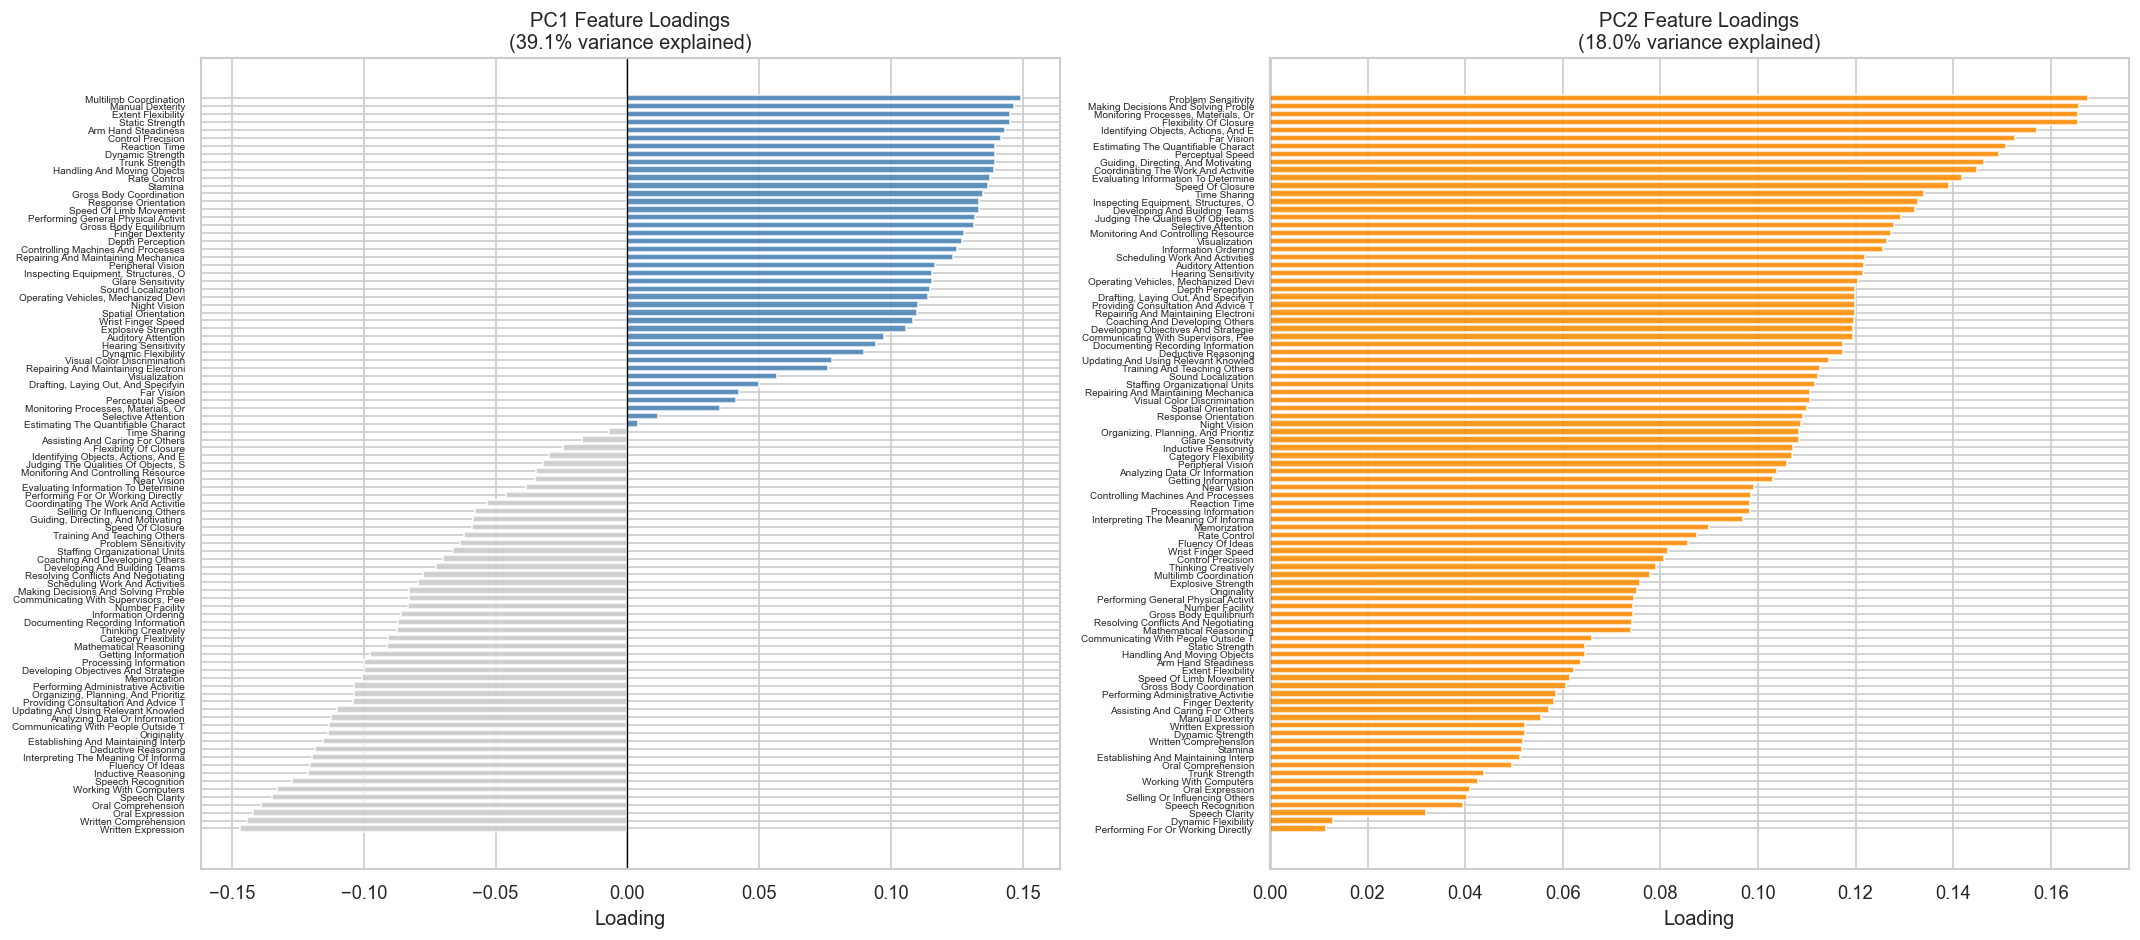

In [40]:
# Visualize PC1 and PC2 loadings
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, pc, color in zip(axes, ['PC1', 'PC2'], ['steelblue', 'darkorange']):
    pc_load = loadings[pc].sort_values()
    colors_bar = [color if v > 0 else '#cccccc' for v in pc_load.values]
    ax.barh(
        [c.replace('_', ' ').title()[:35] for c in pc_load.index],
        pc_load.values,
        color=colors_bar, alpha=0.85
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} Feature Loadings\n'
                 f'({exp_var[int(pc[2:])-1]*100:.1f}% variance explained)',
                 fontsize=12)
    ax.set_xlabel('Loading')
    ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

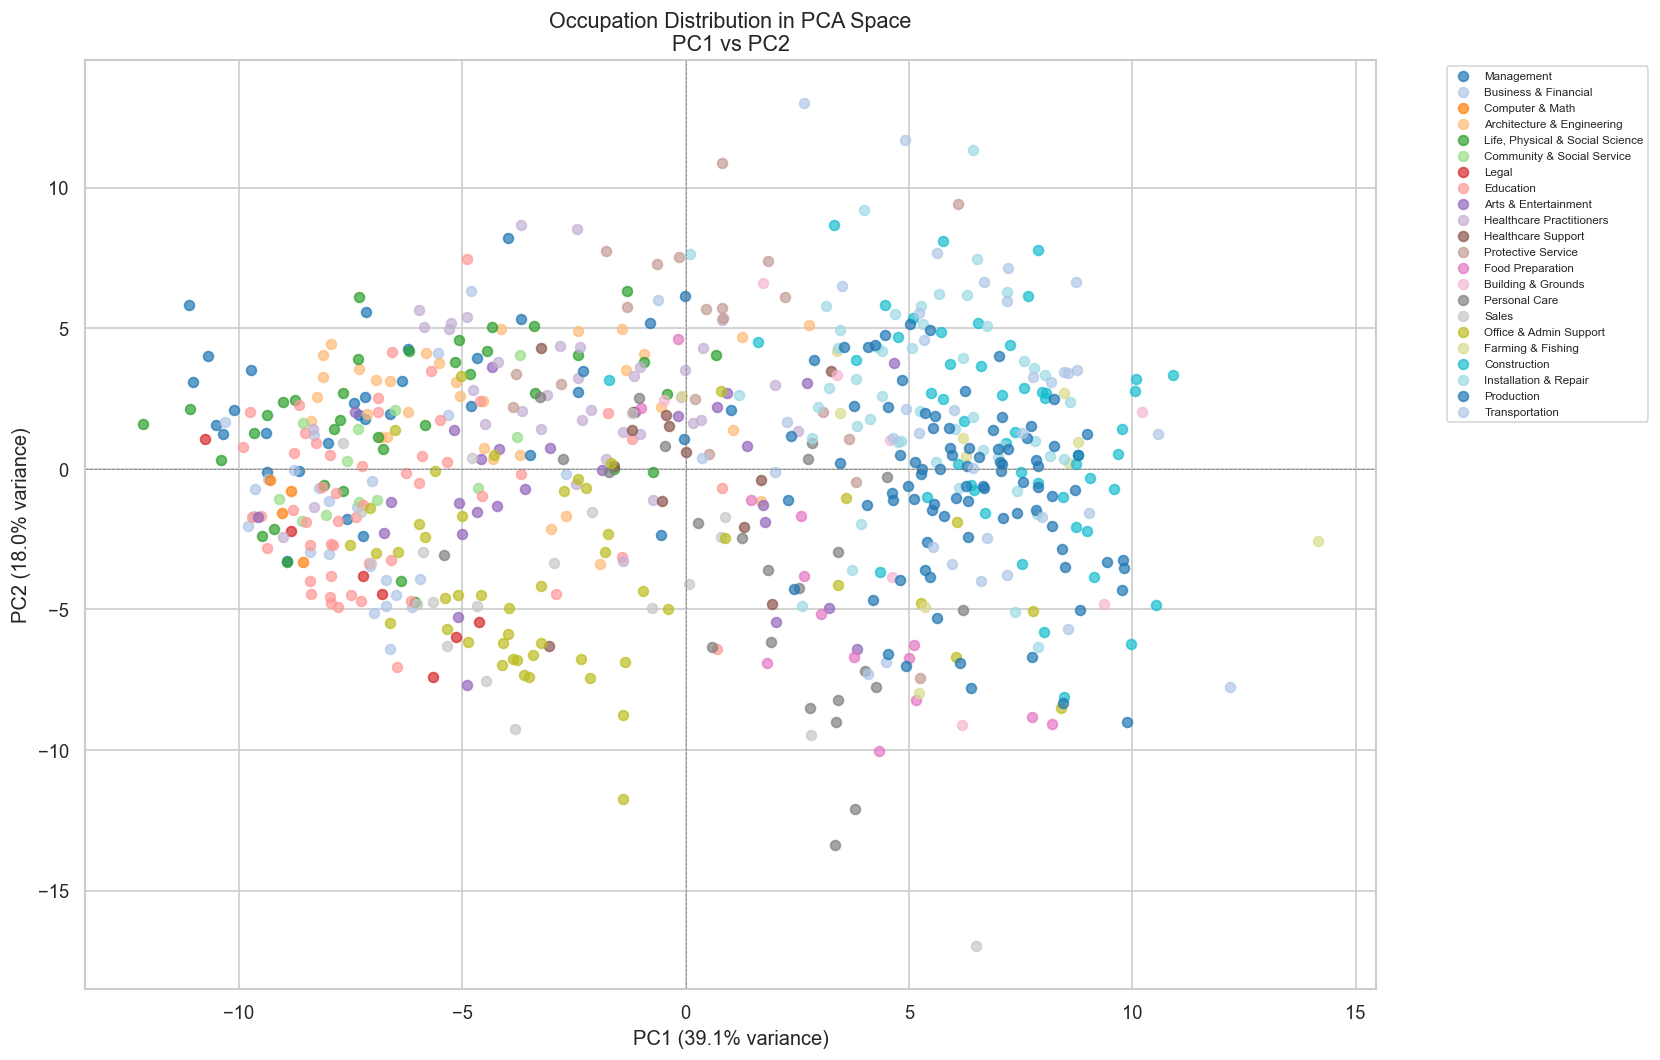

In [41]:
# PC1 vs PC2 scatter — colored by occupation group
# Show how occupations separate in PCA space
pc_df = pd.DataFrame({
    'PC1': components[:, 0],
    'PC2': components[:, 1],
    'occ_major_group': data['occ_major_group'],
    'OCC_TITLE': data['OCC_TITLE'],
    'AIOE': data['AIOE']
})

fig, ax = plt.subplots(figsize=(14, 9))
groups = pc_df['occ_major_group'].unique()
palette = sns.color_palette('tab20', len(groups))

for group, color in zip(groups, palette):
    sub = pc_df[pc_df['occ_major_group'] == group]
    ax.scatter(sub['PC1'], sub['PC2'],
               label=group, alpha=0.7, s=35, color=color)

ax.set_title('Occupation Distribution in PCA Space\nPC1 vs PC2', fontsize=13)
ax.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}% variance)')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

## 5. Weight Components by AIOE Correlation

In [42]:
# Correlate each PCA component with Felten AIOE
correlations = []
for i in range(N_COMPONENTS):
    r, p = stats.pearsonr(components[:, i], data['AIOE'])
    correlations.append({
        'component': f'PC{i+1}',
        'pc_index': i,
        'r': r,
        'p': p,
        'abs_r': abs(r),
        'explained_var': exp_var[i]
    })

corr_df = pd.DataFrame(correlations)
print('Component correlations with Felten AIOE:')
print(f'{"Component":<12} {"r":<10} {"p":<12} {"|r|":<10} {"Exp.Var":<10}')
print('-' * 54)
for _, row in corr_df.sort_values('abs_r', ascending=False).iterrows():
    sig = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else ''))
    print(f"{row['component']:<12} {row['r']:<10.4f} {row['p']:<12.4f} "
          f"{row['abs_r']:<10.4f} {row['explained_var']:<10.4f} {sig}")

print('\nSignificance: *** p<0.001  ** p<0.01  * p<0.05')

Component correlations with Felten AIOE:
Component    r          p            |r|        Exp.Var   
------------------------------------------------------
PC1          -0.9427    0.0000       0.9427     0.3909     ***
PC3          -0.2118    0.0000       0.2118     0.0683     ***
PC9          -0.1024    0.0087       0.1024     0.0164     **
PC2          -0.0978    0.0123       0.0978     0.1802     *
PC4          -0.0755    0.0533       0.0755     0.0380     
PC7          0.0642     0.1006       0.0642     0.0213     
PC6          -0.0581    0.1373       0.0581     0.0249     
PC8          -0.0518    0.1855       0.0518     0.0189     
PC5          -0.0454    0.2464       0.0454     0.0304     
PC17         -0.0350    0.3710       0.0350     0.0066     
PC10         0.0273     0.4848       0.0273     0.0115     
PC11         -0.0271    0.4884       0.0271     0.0113     
PC20         0.0214     0.5843       0.0214     0.0054     
PC14         0.0161     0.6810       0.0161     0.0082  

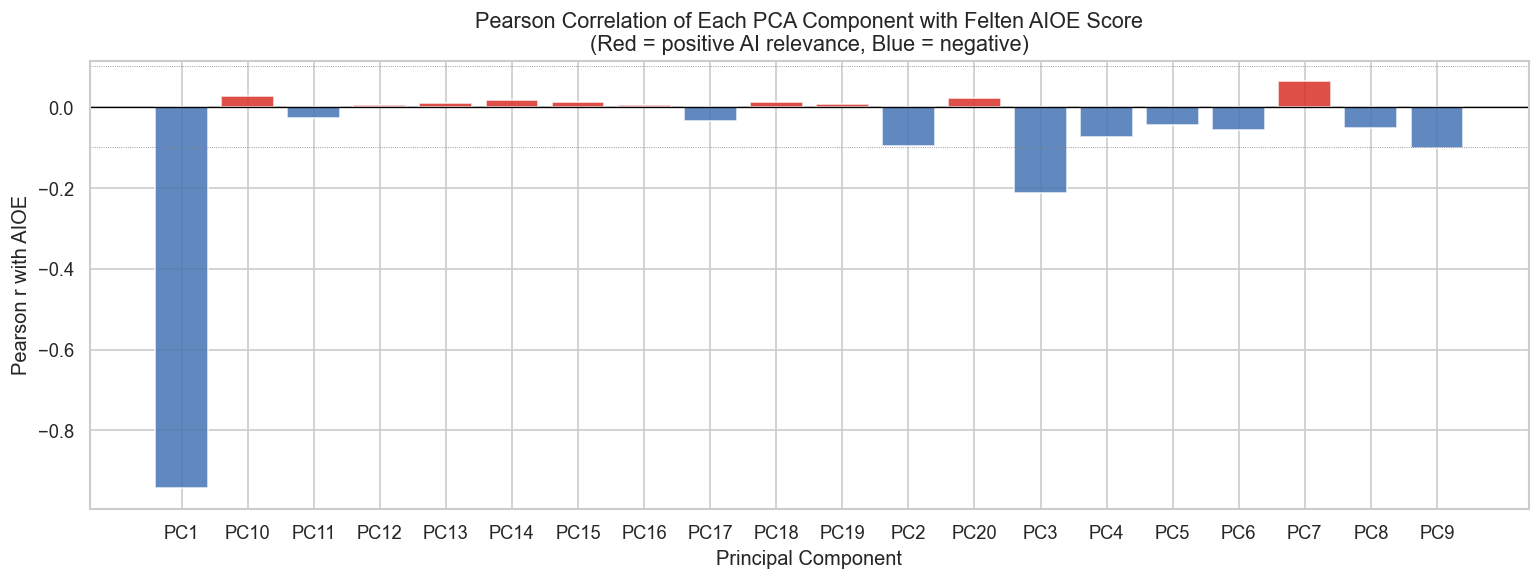

In [43]:
# Visualize component-AIOE correlations
corr_sorted = corr_df.sort_values('component')

fig, ax = plt.subplots(figsize=(13, 5))
colors_bar = ['#d73027' if r > 0 else '#4575b4'
              for r in corr_sorted['r']]
ax.bar(corr_sorted['component'], corr_sorted['r'],
       color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.1, color='gray', linewidth=0.5, linestyle=':')
ax.axhline(-0.1, color='gray', linewidth=0.5, linestyle=':')
ax.set_title('Pearson Correlation of Each PCA Component with Felten AIOE Score\n'
             '(Red = positive AI relevance, Blue = negative)', fontsize=13)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Pearson r with AIOE')
plt.tight_layout()
plt.show()

## 6. Build UAIOE Score 

In [44]:
# Version 1 (UAIOE): Weight components by correlation with Felten AIOE. AI-relevant components get higher weight.
# Version 2 (UAIOE_ev): Weight components by explained variance only. Standard PCA reconstruction — no AIOE signal used.

In [45]:
# Version 1: AIOE-correlation weighted 
# Get weights in component order (PC1, PC2, ... PC20)
weights_aioe = corr_df.sort_values('component')['r'].values

uaioe_raw = components @ weights_aioe
data['UAIOE'] = stats.zscore(uaioe_raw)

print('UAIOE (AIOE-weighted) distribution:')
print(data['UAIOE'].describe().round(3))

# Version 2: Explained variance weighted 
# explained variance ratio as weights
weights_ev = exp_var  

uaioe_ev_raw = components @ weights_ev
data['UAIOE_ev'] = stats.zscore(uaioe_ev_raw)

print('\nUAIOE_ev (variance-weighted) distribution:')
print(data['UAIOE_ev'].describe().round(3))

UAIOE (AIOE-weighted) distribution:
count    655.000
mean       0.000
std        1.001
min       -2.377
25%       -0.921
50%        0.020
75%        0.919
max        2.005
Name: UAIOE, dtype: float64

UAIOE_ev (variance-weighted) distribution:
count    655.000
mean       0.000
std        1.001
min       -1.801
25%       -0.937
50%        0.080
75%        0.891
max        2.000
Name: UAIOE_ev, dtype: float64


/var/folders/h6/kmzh5bqx085c_v5hlbmc7dsw0000gn/T/ipykernel_59755/938640810.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['UAIOE'] = stats.zscore(uaioe_raw)
/var/folders/h6/kmzh5bqx085c_v5hlbmc7dsw0000gn/T/ipykernel_59755/938640810.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['UAIOE_ev'] = stats.zscore(uaioe_ev_raw)


In [46]:
# Compare both versions against Felten AIOE
r1, p1 = stats.pearsonr(data['UAIOE'],    data['AIOE'])
r2, p2 = stats.pearsonr(data['UAIOE_ev'], data['AIOE'])

print('=' * 55)
print('Comparison of UAIOE versions vs Felten AIOE')
print('=' * 55)
print(f'UAIOE (AIOE-weighted):     r={r1:.4f}, p={p1:.6f}')
print(f'UAIOE_ev (EV-weighted):    r={r2:.4f}, p={p2:.6f}')
print()
print(f'Better alignment with AIOE: {"UAIOE" if abs(r1) > abs(r2) else "UAIOE_ev"}')
print()
print('Interpretation:')
print(f'  UAIOE uses Felten AIOE as a validation signal to identify')
print(f'  which O*NET dimensions are AI-relevant.')
print(f'  UAIOE_ev is a naive PCA reconstruction with no AI signal.')
print(f'  The difference in r shows what the AIOE-weighting adds.')

Comparison of UAIOE versions vs Felten AIOE
UAIOE (AIOE-weighted):     r=0.9419, p=0.000000
UAIOE_ev (EV-weighted):    r=-0.9449, p=0.000000

Better alignment with AIOE: UAIOE_ev

Interpretation:
  UAIOE uses Felten AIOE as a validation signal to identify
  which O*NET dimensions are AI-relevant.
  UAIOE_ev is a naive PCA reconstruction with no AI signal.
  The difference in r shows what the AIOE-weighting adds.


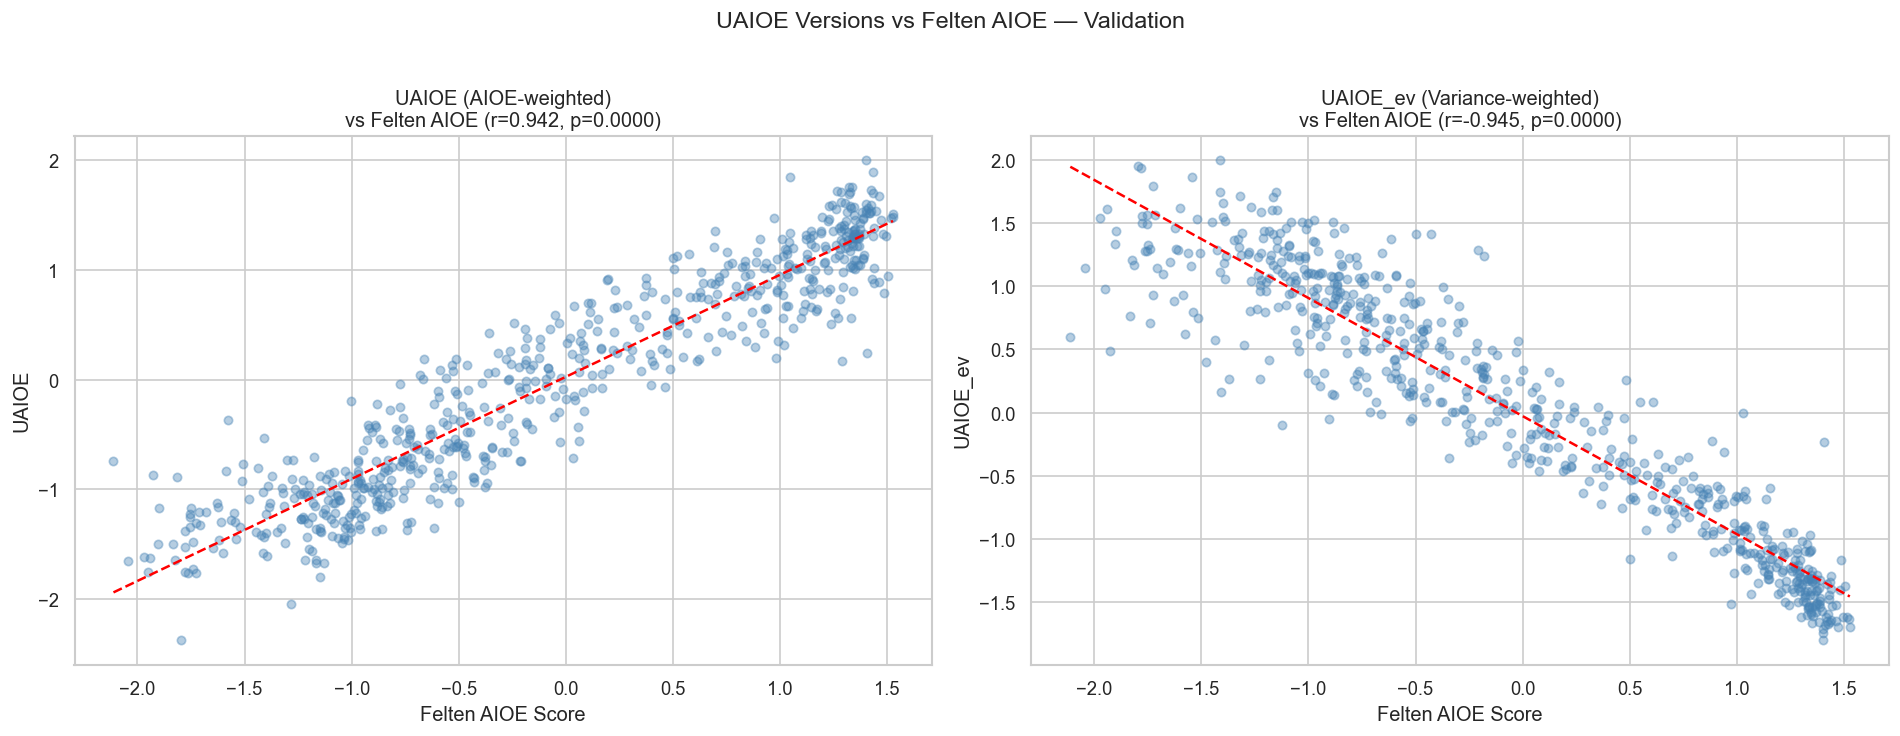

In [47]:
# Scatter plots: both versions vs AIOE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, label, r, p in zip(
    axes,
    ['UAIOE', 'UAIOE_ev'],
    ['UAIOE (AIOE-weighted)', 'UAIOE_ev (Variance-weighted)'],
    [r1, r2], [p1, p2]
):
    ax.scatter(data['AIOE'], data[col],
               alpha=0.4, s=25, color='steelblue')
    m, b = np.polyfit(data['AIOE'], data[col], 1)
    x_line = np.linspace(data['AIOE'].min(), data['AIOE'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red',
            linewidth=1.5, linestyle='--')
    ax.set_title(f'{label}\nvs Felten AIOE (r={r:.3f}, p={p:.4f})',
                 fontsize=12)
    ax.set_xlabel('Felten AIOE Score')
    ax.set_ylabel(col)

plt.suptitle('UAIOE Versions vs Felten AIOE — Validation',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

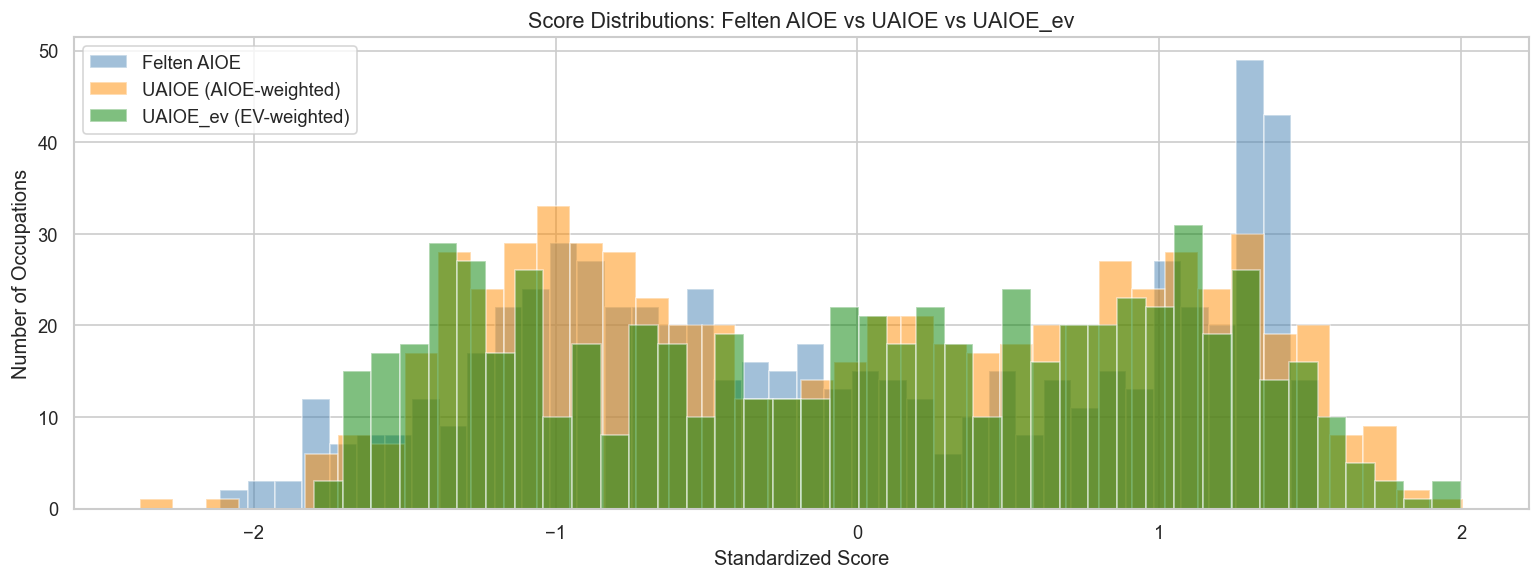

In [48]:
# Distribution comparison: UAIOE vs AIOE vs UAIOE_ev
fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(data['AIOE'],    bins=40, alpha=0.5, label='Felten AIOE',
        color='steelblue', edgecolor='white')
ax.hist(data['UAIOE'],   bins=40, alpha=0.5, label='UAIOE (AIOE-weighted)',
        color='darkorange', edgecolor='white')
ax.hist(data['UAIOE_ev'],bins=40, alpha=0.5, label='UAIOE_ev (EV-weighted)',
        color='green', edgecolor='white')

ax.set_title('Score Distributions: Felten AIOE vs UAIOE vs UAIOE_ev', fontsize=13)
ax.set_xlabel('Standardized Score')
ax.set_ylabel('Number of Occupations')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Validate UAIOE vs Felten AIOE

In [49]:
# Rank occupations by both scores
data['AIOE_rank']  = data['AIOE'].rank(ascending=False).astype(int)
data['UAIOE_rank'] = data['UAIOE'].rank(ascending=False).astype(int)
data['rank_diff']  = (data['UAIOE_rank'] - data['AIOE_rank'])
data['abs_rank_diff'] = data['rank_diff'].abs()

print('Top 10 occupations by UAIOE score:')
print(data.nlargest(10, 'UAIOE')
      [['OCC_CODE', 'OCC_TITLE', 'UAIOE', 'AIOE',
        'UAIOE_rank', 'AIOE_rank']]
      .round(3).to_string(index=False))

print('\nBottom 10 occupations by UAIOE score:')
print(data.nsmallest(10, 'UAIOE')
      [['OCC_CODE', 'OCC_TITLE', 'UAIOE', 'AIOE',
        'UAIOE_rank', 'AIOE_rank']]
      .round(3).to_string(index=False))

Top 10 occupations by UAIOE score:
OCC_CODE                                                OCC_TITLE  UAIOE  AIOE  UAIOE_rank  AIOE_rank
 19-3032                  Industrial-Organizational Psychologists  2.005 1.402           1         27
 19-1041                                          Epidemiologists  1.892 1.436           2         16
 11-9032 Education Administrators, Kindergarten through Secondary  1.846 1.049           3        152
 11-1011                                         Chief Executives  1.759 1.334           4         66
 11-3121                                 Human Resources Managers  1.755 1.320           5         76
 19-3022                                       Survey Researchers  1.727 1.427           6         20
 11-2022                                           Sales Managers  1.718 1.266           7        102
 11-3131                        Training and Development Managers  1.712 1.284           8         94
 23-1011                                       

/var/folders/h6/kmzh5bqx085c_v5hlbmc7dsw0000gn/T/ipykernel_59755/3160384827.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['AIOE_rank']  = data['AIOE'].rank(ascending=False).astype(int)
/var/folders/h6/kmzh5bqx085c_v5hlbmc7dsw0000gn/T/ipykernel_59755/3160384827.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['UAIOE_rank'] = data['UAIOE'].rank(ascending=False).astype(int)
/var/folders/h6/kmzh5bqx085c_v5hlbmc7dsw0000gn/T/ipykernel_59755/3160384827.py:4: PerformanceWarning: DataFrame is highly fragmented.  This i

In [50]:
# Occupations with biggest rank changes — where UAIOE differs most from AIOE
print('Occupations with largest UPWARD rank change (UAIOE ranks higher than AIOE):')
print(data.nsmallest(10, 'rank_diff')
      [['OCC_CODE', 'OCC_TITLE', 'AIOE_rank', 'UAIOE_rank', 'rank_diff']]
      .to_string(index=False))

print('\nOccupations with largest DOWNWARD rank change (UAIOE ranks lower than AIOE):')
print(data.nlargest(10, 'rank_diff')
      [['OCC_CODE', 'OCC_TITLE', 'AIOE_rank', 'UAIOE_rank', 'rank_diff']]
      .to_string(index=False))

print(f'\nMean absolute rank change: {data["abs_rank_diff"].mean():.1f} positions')
print(f'Median absolute rank change: {data["abs_rank_diff"].median():.1f} positions')

Occupations with largest UPWARD rank change (UAIOE ranks higher than AIOE):
OCC_CODE                                                  OCC_TITLE  AIOE_rank  UAIOE_rank  rank_diff
 27-2032                                             Choreographers        621         376       -245
 39-9031            Exercise Trainers and Group Fitness Instructors        655         450       -205
 31-9011                                         Massage Therapists        606         402       -204
 35-9011 Dining Room and Cafeteria Attendants and Bartender Helpers        650         477       -173
 19-3091                          Anthropologists and Archeologists        218          55       -163
 27-1026                 Merchandise Displayers and Window Trimmers        522         359       -163
 27-2021                            Athletes and Sports Competitors        645         483       -162
 47-3013                                      Helpers--Electricians        614         455       -159
 47-21

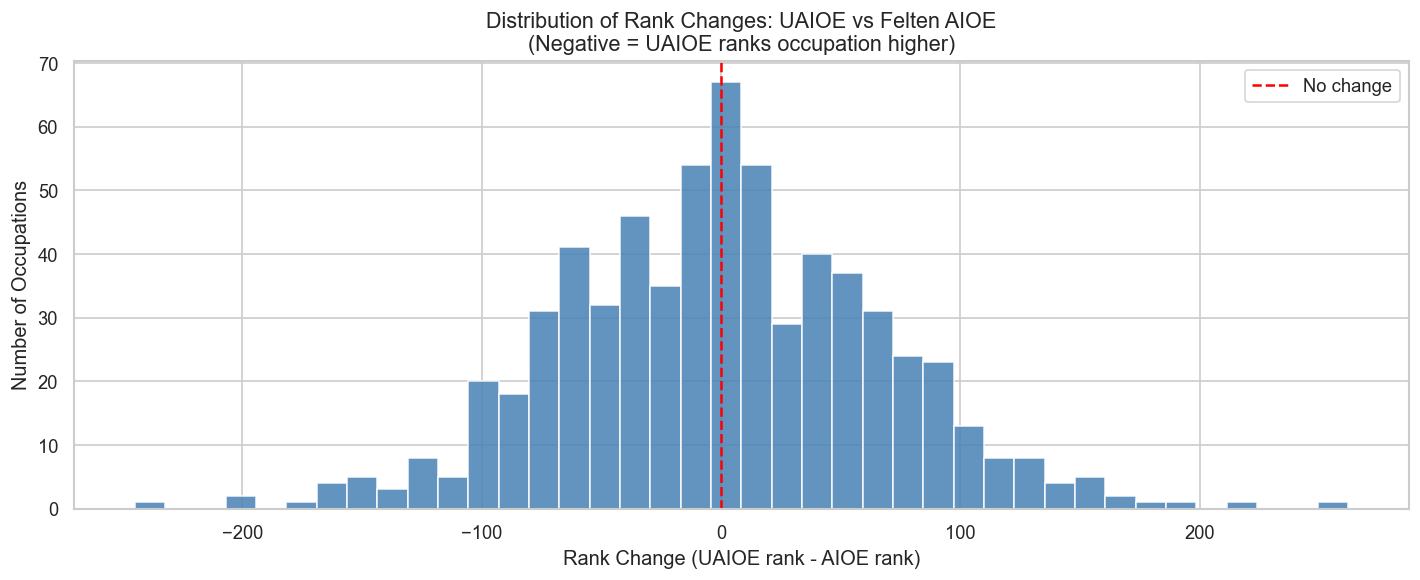

In [51]:
# Rank change distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(data['rank_diff'], bins=40,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5,
           label='No change')
ax.set_title('Distribution of Rank Changes: UAIOE vs Felten AIOE\n'
             '(Negative = UAIOE ranks occupation higher)', fontsize=13)
ax.set_xlabel('Rank Change (UAIOE rank - AIOE rank)')
ax.set_ylabel('Number of Occupations')
ax.legend()
plt.tight_layout()
plt.show()

## 8. K-Means Clustering

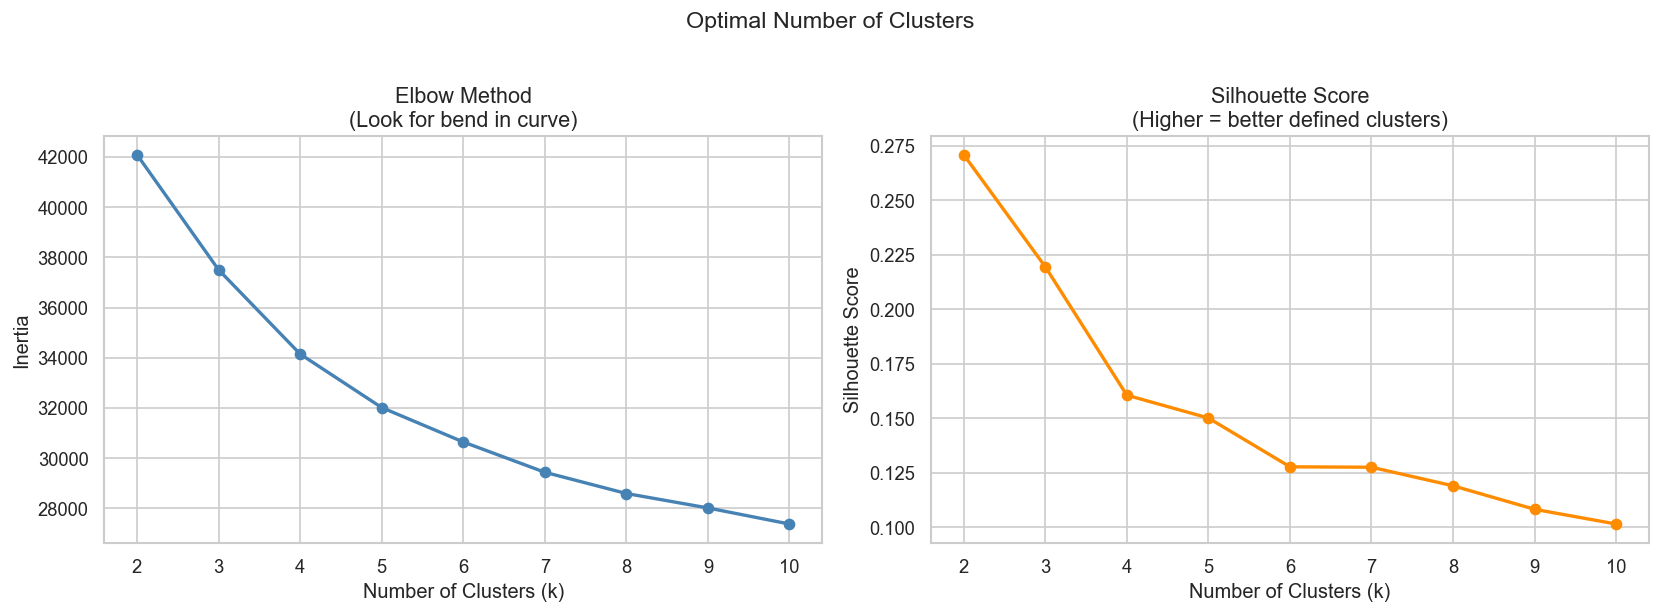

Best k by silhouette score: 2
Silhouette scores: {2: 0.271, 3: 0.22, 4: 0.161, 5: 0.15, 6: 0.128, 7: 0.128, 8: 0.119, 9: 0.108, 10: 0.102}


In [52]:
# Elbow method to find optimal k 
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels,
                                        sample_size=500,
                                        random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o',
             color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method\n(Look for bend in curve)', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouettes, marker='o',
             color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score\n(Higher = better defined clusters)', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

plt.suptitle('Optimal Number of Clusters', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'Best k by silhouette score: {best_k}')
print(f'Silhouette scores: {dict(zip(k_range, [round(s,3) for s in silhouettes]))}')

In [53]:
# Fit final k-means model 
FINAL_K = 5

km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
data['cluster'] = km_final.fit_predict(X_scaled)

print(f'Cluster sizes (k={FINAL_K}):')
print(data['cluster'].value_counts().sort_index())

/var/folders/h6/kmzh5bqx085c_v5hlbmc7dsw0000gn/T/ipykernel_59755/1722167219.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['cluster'] = km_final.fit_predict(X_scaled)


Cluster sizes (k=5):
cluster
0    194
1    138
2     93
3    136
4     94
Name: count, dtype: int64


In [54]:
# Profile each cluster
cluster_profile = data.groupby('cluster').agg(
    n_occupations=('OCC_CODE', 'count'),
    mean_UAIOE=('UAIOE', 'mean'),
    mean_AIOE=('AIOE', 'mean'),
    mean_wage_2024=('real_median_wage_2024', 'mean'),
    mean_emp_change=('emp_change_pct_19_24', 'mean'),
    mean_wage_change=('wage_change_pct_19_24', 'mean')
).round(3)

print('Cluster profiles:')
print(cluster_profile.to_string())

# Most common occupation group per cluster
print('\nDominant occupation group per cluster:')
for c in range(FINAL_K):
    top_group = (data[data['cluster'] == c]['occ_major_group']
                 .value_counts().index[0])
    n = data[data['cluster'] == c]['occ_major_group'].value_counts().iloc[0]
    print(f'  Cluster {c}: {top_group} ({n} occupations)')

Cluster profiles:
         n_occupations  mean_UAIOE  mean_AIOE  mean_wage_2024  mean_emp_change  mean_wage_change
cluster                                                                                         
0                  194      -1.018     -1.003       55665.412           -6.549             5.632
1                  138       0.248      0.020       70273.696            4.309             2.932
2                   93       0.805      1.087       63335.806           -5.952             1.907
3                  136       1.287      1.145       95767.794            8.859            -1.498
4                   94      -0.921     -0.891       41745.319           -6.672            12.345

Dominant occupation group per cluster:
  Cluster 0: Production (63 occupations)
  Cluster 1: Healthcare Practitioners (33 occupations)
  Cluster 2: Office & Admin Support (33 occupations)
  Cluster 3: Education (31 occupations)
  Cluster 4: Production (23 occupations)


In [55]:
# Assign cluster labels based on profile 
cluster_labels = {
    0: 'Low Exposure Manual & Technical',
    1: 'Moderate Exposure Service & Healthcare',
    2: 'High Exposure Analytical & Office',
    3: 'Highest Exposure Knowledge & Management',
    4: 'Low Exposure Routine Service'
}

data['cluster_label'] = data['cluster'].map(cluster_labels)
data = data.copy()  

# Sample occupations from each cluster
print('Sample occupations per cluster:')
for c in range(FINAL_K):
    sample = (data[data['cluster'] == c]
              .nlargest(3, 'UAIOE')[['OCC_TITLE', 'UAIOE']]
              .round(3))
    print(f'\n  Cluster {c} (top 3 by UAIOE):')
    for _, row in sample.iterrows():
        print(f'    {row["OCC_TITLE"]}: {row["UAIOE"]:.3f}')

Sample occupations per cluster:

  Cluster 0 (top 3 by UAIOE):
    Surveying and Mapping Technicians: -0.286
    Camera Operators, Television, Video, and Film: -0.317
    Transportation Inspectors: -0.382

  Cluster 1 (top 3 by UAIOE):
    Optometrists: 1.013
    Audiologists: 0.986
    Meeting, Convention, and Event Planners: 0.932

  Cluster 2 (top 3 by UAIOE):
    Genetic Counselors: 1.481
    History Teachers, Postsecondary: 1.385
    Sociology Teachers, Postsecondary: 1.373

  Cluster 3 (top 3 by UAIOE):
    Industrial-Organizational Psychologists: 2.005
    Epidemiologists: 1.892
    Education Administrators, Kindergarten through Secondary: 1.846

  Cluster 4 (top 3 by UAIOE):
    Demonstrators and Product Promoters: 0.046
    Gambling and Sports Book Writers and Runners: -0.064
    Postal Service Clerks: -0.106


/var/folders/h6/kmzh5bqx085c_v5hlbmc7dsw0000gn/T/ipykernel_59755/3971704971.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['cluster_label'] = data['cluster'].map(cluster_labels)


/var/folders/h6/kmzh5bqx085c_v5hlbmc7dsw0000gn/T/ipykernel_59755/2044818743.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


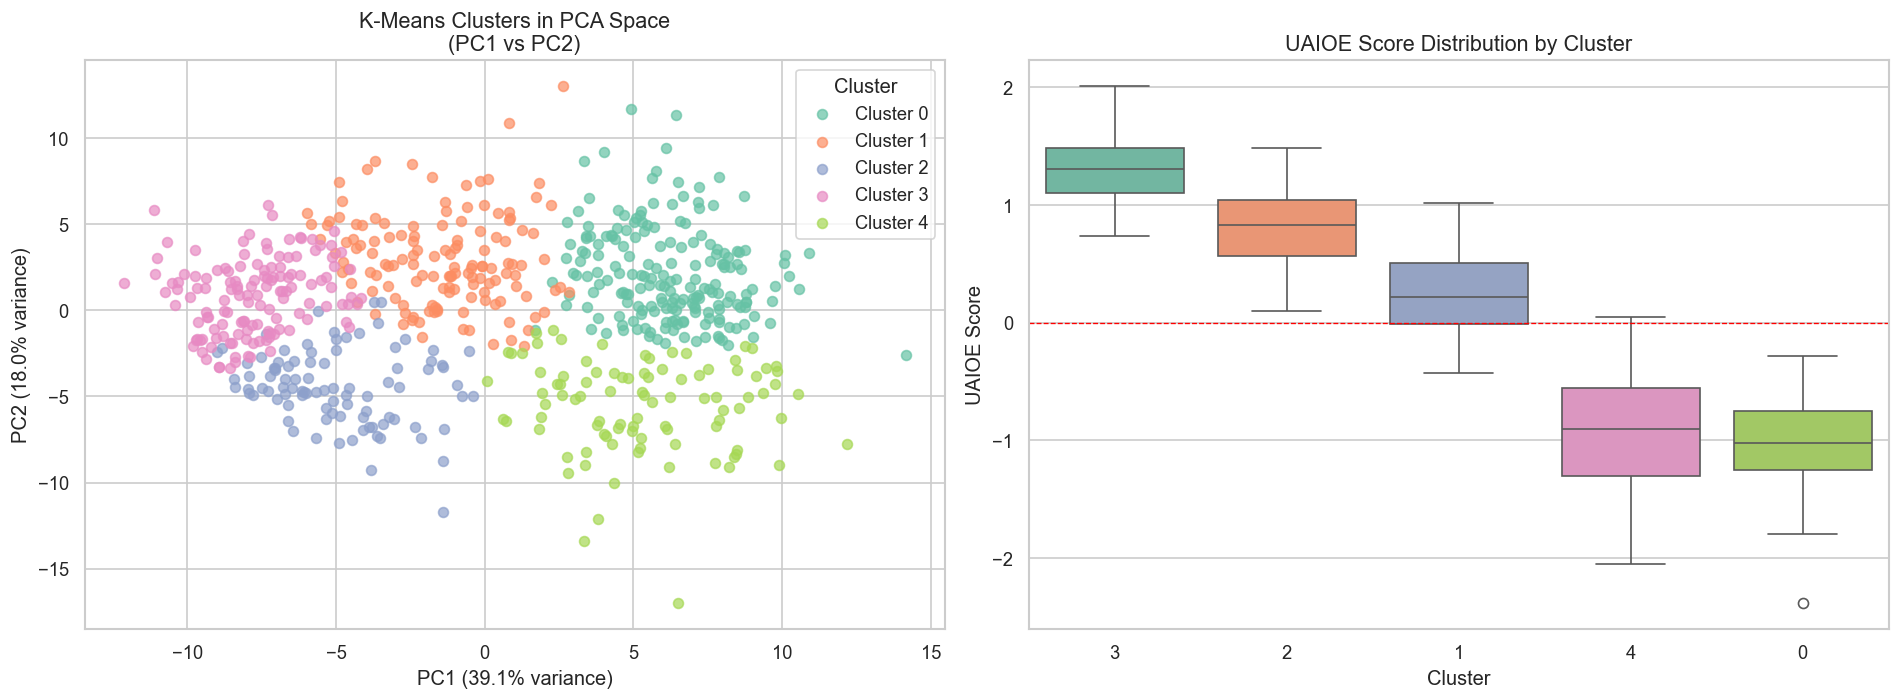

In [56]:
# Visualize clusters in PCA space 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette_k = sns.color_palette('Set2', FINAL_K)

# PC1 vs PC2
for c in range(FINAL_K):
    mask = data['cluster'] == c
    axes[0].scatter(
        components[mask, 0], components[mask, 1],
        label=f'Cluster {c}', alpha=0.7, s=35,
        color=palette_k[c]
    )
axes[0].set_title('K-Means Clusters in PCA Space\n(PC1 vs PC2)', fontsize=13)
axes[0].set_xlabel(f'PC1 ({exp_var[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({exp_var[1]*100:.1f}% variance)')
axes[0].legend(title='Cluster')

# UAIOE score by cluster — boxplot
cluster_order = (data.groupby('cluster')['UAIOE']
                 .mean().sort_values(ascending=False).index)
sns.boxplot(
    data=data, x='cluster', y='UAIOE',
    order=cluster_order, palette='Set2', ax=axes[1]
)
axes[1].set_title('UAIOE Score Distribution by Cluster', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('UAIOE Score')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

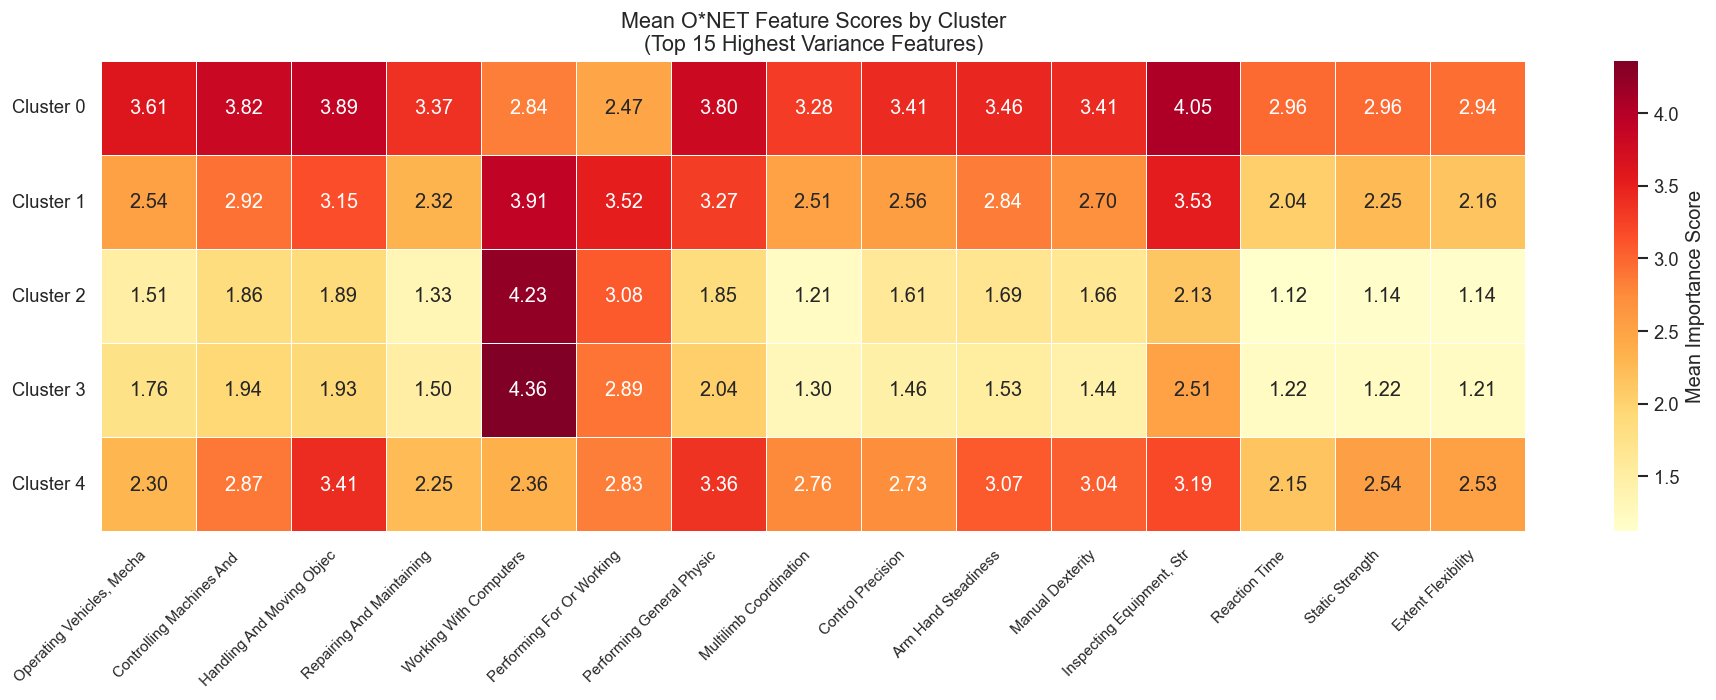

In [57]:
# Cluster heatmap — mean feature scores
# Use top 15 highest variance features for readability
feature_variance = data[feature_cols].var().sort_values(ascending=False)
top_features = feature_variance.head(15).index.tolist()

cluster_means = data.groupby('cluster')[top_features].mean()
cluster_means.index = [f'Cluster {i}' for i in cluster_means.index]
cluster_means.columns = [
    c.replace('_', ' ').title()[:25]
    for c in cluster_means.columns
]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    cluster_means, cmap='YlOrRd', annot=True,
    fmt='.2f', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean Importance Score'}
)
ax.set_title('Mean O*NET Feature Scores by Cluster\n'
             '(Top 15 Highest Variance Features)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Occupation Rankings

In [58]:
# Top 20 and bottom 20 by UAIOE
rank_cols = ['OCC_CODE', 'OCC_TITLE', 'occ_major_group',
             'UAIOE', 'AIOE', 'UAIOE_rank', 'AIOE_rank',
             'real_median_wage_2024',
             'emp_change_pct_19_24', 'wage_change_pct_19_24']

print('TOP 20 HIGHEST UAIOE OCCUPATIONS:')
print(data.nlargest(20, 'UAIOE')[rank_cols].round(3).to_string(index=False))

print('\nBOTTOM 20 LOWEST UAIOE OCCUPATIONS:')
print(data.nsmallest(20, 'UAIOE')[rank_cols].round(3).to_string(index=False))

TOP 20 HIGHEST UAIOE OCCUPATIONS:
OCC_CODE                                                OCC_TITLE                 occ_major_group  UAIOE  AIOE  UAIOE_rank  AIOE_rank  real_median_wage_2024  emp_change_pct_19_24  wage_change_pct_19_24
 19-3032                  Industrial-Organizational Psychologists Life, Physical & Social Science  2.005 1.402           1         27               109840.0                66.667                  1.685
 19-1041                                          Epidemiologists Life, Physical & Social Science  1.892 1.436           2         16                83980.0                54.656                  1.718
 11-9032 Education Administrators, Kindergarten through Secondary                      Management  1.846 1.049           3        152               104070.0                17.936                 -7.174
 11-1011                                         Chief Executives                      Management  1.759 1.334           4         66               206420.0  

Mean UAIOE by occupation group:
                                 mean_UAIOE  mean_AIOE   n
occ_major_group                                           
Computer & Math                       1.502      1.443   4
Management                            1.216      1.000  28
Business & Financial                  1.119      1.190  25
Education                             1.115      1.004  52
Community & Social Service            1.079      0.824  12
Legal                                 1.065      1.381   7
Life, Physical & Social Science       1.045      0.914  37
Architecture & Engineering            0.702      0.827  33
Sales                                 0.482      0.604  20
Healthcare Practitioners              0.462      0.117  37
Arts & Entertainment                  0.395      0.283  29
Office & Admin Support                0.383      0.673  50
Healthcare Support                    0.039     -0.384  13
Protective Service                   -0.146     -0.381  20
Personal Care           

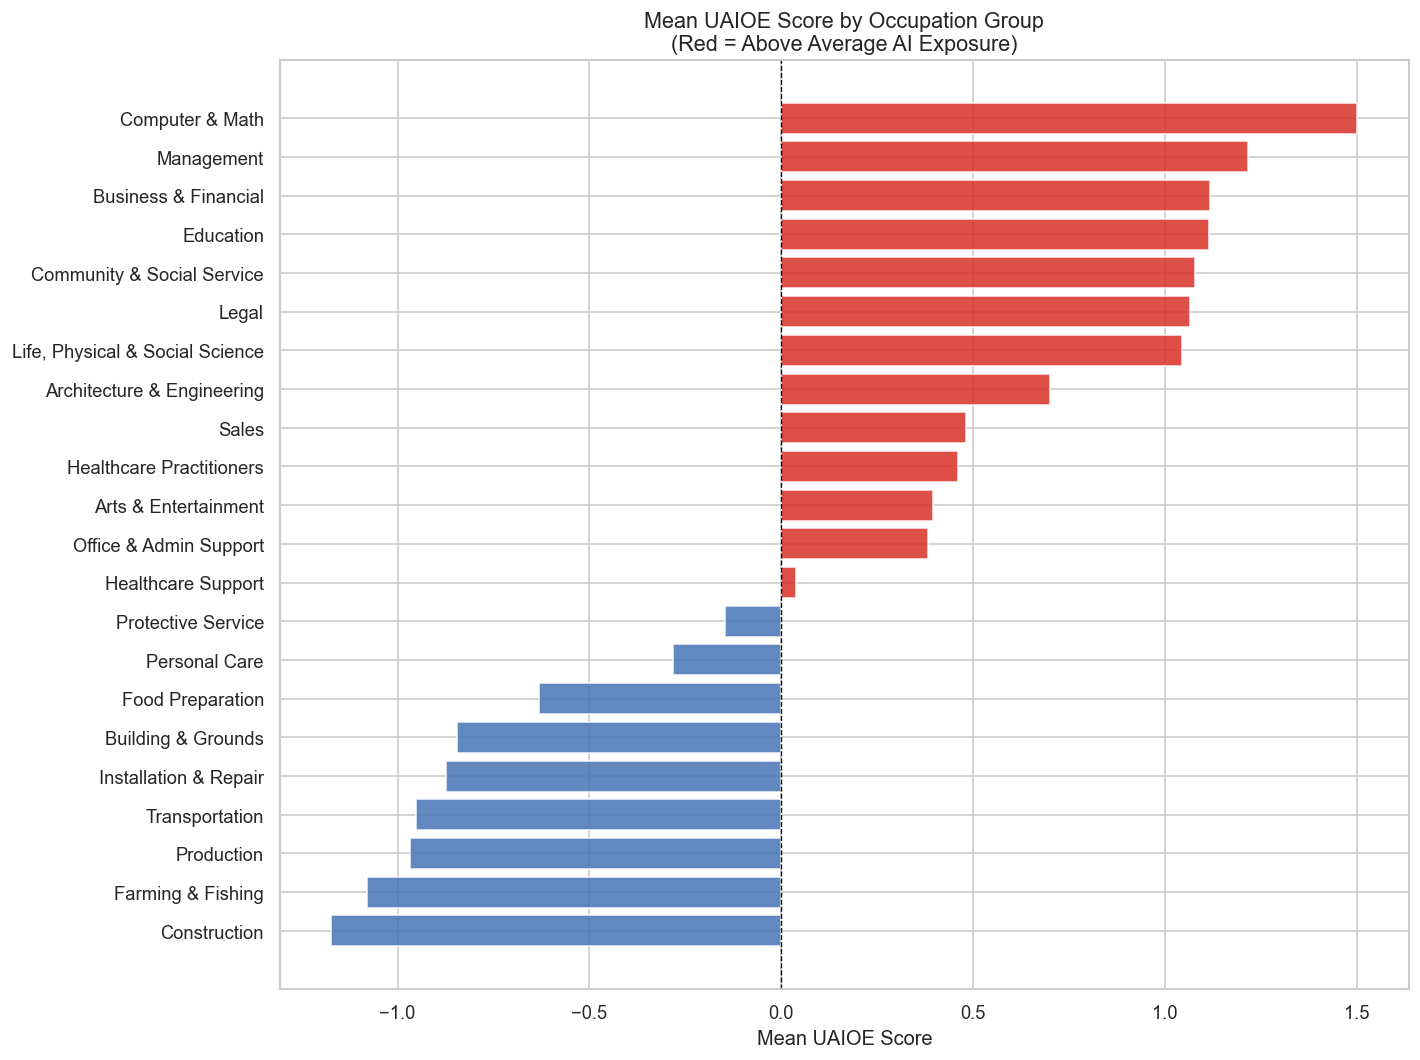

In [59]:
# UAIOE by occupation group — mean score
group_uaioe = (data.groupby('occ_major_group')
               .agg(mean_UAIOE=('UAIOE', 'mean'),
                    mean_AIOE=('AIOE', 'mean'),
                    n=('OCC_CODE', 'count'))
               .sort_values('mean_UAIOE', ascending=False))

print('Mean UAIOE by occupation group:')
print(group_uaioe.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 9))
colors_g = ['#d73027' if v > 0 else '#4575b4'
            for v in group_uaioe['mean_UAIOE'].values[::-1]]
ax.barh(
    group_uaioe.index[::-1],
    group_uaioe['mean_UAIOE'].values[::-1],
    color=colors_g, alpha=0.85
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean UAIOE Score by Occupation Group\n'
             '(Red = Above Average AI Exposure)', fontsize=13)
ax.set_xlabel('Mean UAIOE Score')
plt.tight_layout()
plt.show()

## 10. Save Outputs

In [61]:
# Final checks
assert data['OCC_CODE'].nunique() == len(data), 'Duplicate SOC codes'
assert data['UAIOE'].isnull().sum() == 0, 'Missing UAIOE values'

print('Final master table:')
print(f'  Occupations: {len(data)}')
print(f'  Columns:     {data.shape[1]}')
print(f'  New columns: UAIOE, UAIOE_ev, AIOE_rank, UAIOE_rank, '
      f'rank_diff, abs_rank_diff, cluster, cluster_label')

# Standalone UAIOE scores file 
uaioe_standalone = data[[
    'OCC_CODE', 'OCC_TITLE', 'occ_major_group',
    'AIOE', 'AIOE_z', 'UAIOE', 'UAIOE_ev',
    'AIOE_rank', 'UAIOE_rank', 'rank_diff',
    'cluster', 'cluster_label'
]].copy()

uaioe_path = Path('..') / 'data' / 'processed' / 'uaioe_scores.csv'
uaioe_standalone.to_csv(uaioe_path, index=False)
print(f'\nSaved: uaioe_scores.csv ({len(uaioe_standalone)} occupations)')

# Updated master table 
data.to_csv(DATA_PATH, index=False)
print(f'Updated: master_occupations.csv')

# Summary 
print('\n' + '=' * 55)
print('NOTEBOOK 06 SUMMARY')
print('=' * 55)
print(f'Occupations analyzed:          {len(data)}')
print(f'O*NET features used:           {len(feature_cols)}')
print(f'PCA components computed:       {N_COMPONENTS}')
print(f'Components for 80% variance:   {n_80}')
print(f'Components for 90% variance:   {n_90}')
print(f'UAIOE vs AIOE correlation:     r={r1:.3f}')
print(f'UAIOE_ev vs AIOE correlation:  r={r2:.3f}')
print(f'K-Means clusters:              {FINAL_K}')
print(f'Mean absolute rank change:     {data["abs_rank_diff"].mean():.1f}')

Final master table:
  Occupations: 655
  Columns:     130
  New columns: UAIOE, UAIOE_ev, AIOE_rank, UAIOE_rank, rank_diff, abs_rank_diff, cluster, cluster_label

Saved: uaioe_scores.csv (655 occupations)
Updated: master_occupations.csv

NOTEBOOK 06 SUMMARY
Occupations analyzed:          655
O*NET features used:           93
PCA components computed:       20
Components for 80% variance:   10
Components for 90% variance:   1
UAIOE vs AIOE correlation:     r=0.942
UAIOE_ev vs AIOE correlation:  r=-0.945
K-Means clusters:              5
Mean absolute rank change:     52.2
